# Phase 1 Step 1.7 — Agent Types Validation

This notebook validates the Phase 1 agent additions: HK, Contrarian, Influencer, and Passive.

Note: `notebooks/` lives at the project root, so the repo root is `Path.cwd().parent`.

In [1]:
from __future__ import annotations

from pathlib import Path
import sys

import matplotlib.pyplot as plt
import numpy as np

PROJECT_ROOT = Path.cwd().parent
if str(PROJECT_ROOT) not in sys.path:
    sys.path.append(str(PROJECT_ROOT))

from backend.sim.simulation import run_simulation
from backend.sim import agent as agent_module

plt.style.use('seaborn-v0_8-whitegrid')

## Helpers

These helpers run the simulation with a specific agent mix and extract opinion time series.

In [2]:
def run_with_config(agent_mix: dict[str, float], seed: int = 42, overrides: dict | None = None) -> dict:
    config = {
        'N': 100,
        'avg_degree': 16,
        'rewire_prob': 0.1,
        'T': 200,
        'snapshot_interval': 6,
        'alpha': 0.65,
        'beta_pop': 0.2,
        'k_exp': 20,
        'agent_mix': agent_mix,
        'sir_beta': 0.3,
        'sir_gamma': 0.05,
        'initial_opinion_distribution': 'uniform',
        'seed': seed,
    }
    if overrides:
        config.update(overrides)
    return run_simulation(config)


def opinion_timeseries(result: dict) -> np.ndarray:
    histories = np.array(
        [agent['opinion_history'] for agent in result['final_agents']],
        dtype=np.float64,
    )
    return histories.mean(axis=0)


def final_opinions(result: dict) -> np.ndarray:
    return np.array(
        [agent['opinion_history'][-1] for agent in result['final_agents']],
        dtype=np.float64,
    )

## HK Agents — Confidence Bound Sensitivity

Expectation:
- $\epsilon = 0.1$ should form multiple clusters by tick 100.
- $\epsilon = 0.8$ should converge toward consensus by tick 100.

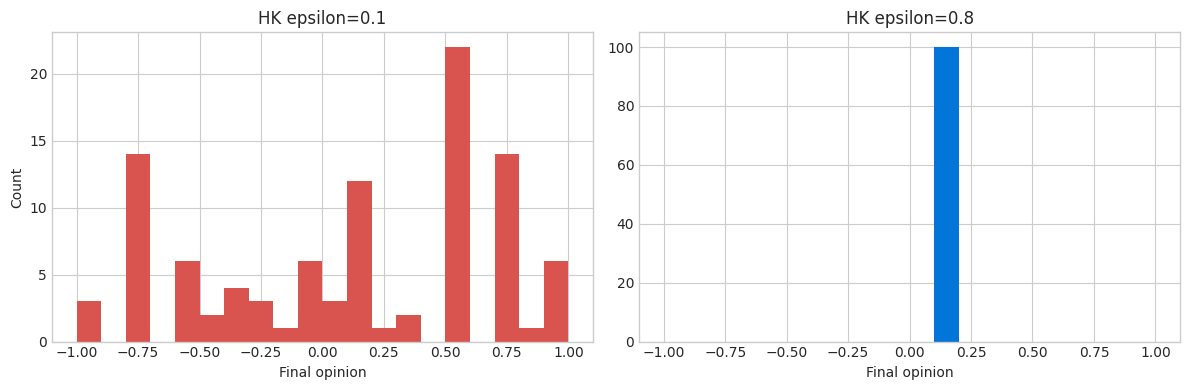

In [8]:
import backend.sim.simulation as sim_module

def run_hk_with_epsilon(epsilon: float, seed: int = 42) -> dict:
    previous = agent_module.HK_CONFIDENCE_BOUND_DEFAULT
    agent_module.HK_CONFIDENCE_BOUND_DEFAULT = epsilon
    try:
        result = run_with_config({'hk': 1.0}, seed=seed)
    finally:
        agent_module.HK_CONFIDENCE_BOUND_DEFAULT = previous
    return result

# Disable feed influence to isolate HK behavior
prev_feed = sim_module.FEED_INFLUENCE_MAX
sim_module.FEED_INFLUENCE_MAX = 0.0
try:
    hk_low = run_hk_with_epsilon(0.1, seed=41)
    hk_high = run_hk_with_epsilon(0.8, seed=41)
finally:
    sim_module.FEED_INFLUENCE_MAX = prev_feed

fig, axes = plt.subplots(1, 2, figsize=(12, 4))
axes[0].hist(final_opinions(hk_low), bins=20, range=(-1, 1), color='#d9534f')
axes[0].set_title('HK epsilon=0.1')
axes[0].set_xlabel('Final opinion')
axes[0].set_ylabel('Count')

axes[1].hist(final_opinions(hk_high), bins=20, range=(-1, 1), color='#0275d8')
axes[1].set_title('HK epsilon=0.8')
axes[1].set_xlabel('Final opinion')

plt.tight_layout()
plt.show()

## Contrarian Agents — Oscillation vs Baseline

Expectation: Contrarian populations should show less stable convergence and more oscillation.

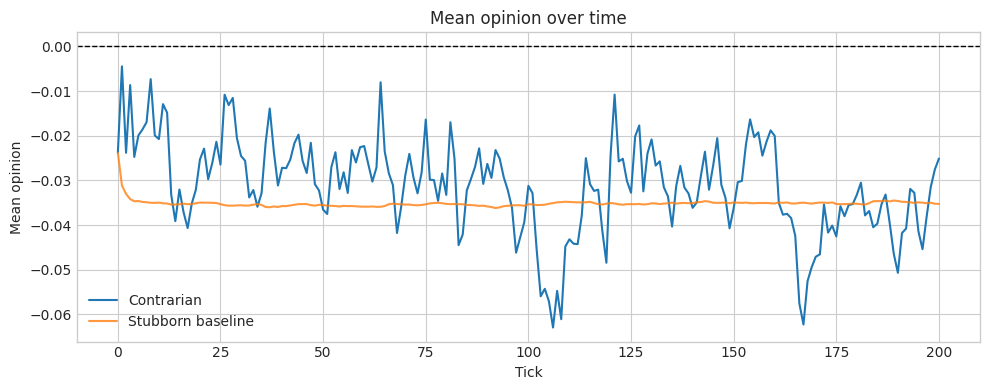

In [4]:
contrarian = run_with_config({'contrarian': 1.0}, seed=7)
baseline = run_with_config({'stubborn': 1.0}, seed=7)

plt.figure(figsize=(10, 4))
plt.plot(opinion_timeseries(contrarian), label='Contrarian')
plt.plot(opinion_timeseries(baseline), label='Stubborn baseline', alpha=0.8)
plt.axhline(0.0, color='black', linewidth=1, linestyle='--')
plt.title('Mean opinion over time')
plt.xlabel('Tick')
plt.ylabel('Mean opinion')
plt.legend()
plt.tight_layout()
plt.show()

## Influencer Agents — Stronger Pull on Neighbors

This test uses one influencer and the rest stubborn agents to reveal the influence effect.
We compare the average distance from the influencer's opinion to all others vs a baseline run.

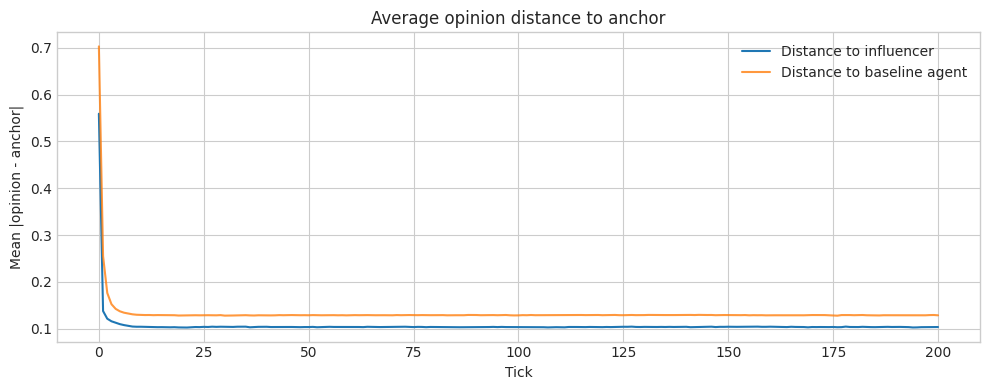

In [6]:
influencer_run = run_with_config({'influencer': 0.01, 'stubborn': 0.99}, seed=11)
baseline_run = run_with_config({'stubborn': 1.0}, seed=11)

def mean_distance_to_anchor(result: dict, anchor_id: int) -> np.ndarray:
    histories = np.array(
        [agent['opinion_history'] for agent in result['final_agents']],
        dtype=np.float64,
    )
    anchor = histories[anchor_id]
    distances = np.abs(histories - anchor)
    return distances.mean(axis=0)

influencer_id = next(
    agent['id'] for agent in influencer_run['final_agents'] if agent['agent_type'] == 'influencer'
 )
baseline_anchor_id = 0

plt.figure(figsize=(10, 4))
plt.plot(
    mean_distance_to_anchor(influencer_run, influencer_id),
    label='Distance to influencer',
 )
plt.plot(
    mean_distance_to_anchor(baseline_run, baseline_anchor_id),
    label='Distance to baseline agent',
    alpha=0.8,
 )
plt.title('Average opinion distance to anchor')
plt.xlabel('Tick')
plt.ylabel('Mean |opinion - anchor|')
plt.legend()
plt.tight_layout()
plt.show()